# NeuroLab: EEG Data Generation and Exploration

This notebook demonstrates how to generate synthetic EEG data for mental state classification.

**Mental States:**
- 0: Relaxed (high alpha, low beta)
- 1: Focused (high beta, moderate alpha)
- 2: Stressed (very high beta, low alpha, elevated gamma)

**Author:** NeuroLab Team  
**License:** MIT

## 1. Setup and Imports

In [1]:
# Install required packages (uncomment if needed on Kaggle)
# !pip install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

/tmp/ipykernel_36694/1595788235.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✓ Imports successful
NumPy version: 1.26.4
Pandas version: 2.2.0


## 2. Data Generation Functions

In [2]:
def generate_realistic_band_powers(state, num_samples=1000):
    """
    Generate realistic frequency band power values for different mental states.
    
    Args:
        state: Mental state ('relaxed', 'focused', or 'stressed')
        num_samples: Number of samples to generate
    
    Returns:
        List of sample dictionaries with frequency band powers
    """
    samples = []
    
    for _ in range(num_samples):
        if state == 'relaxed':
            # Relaxed state: High alpha rhythm
            alpha = np.random.uniform(15, 35)
            beta = np.random.uniform(3, 12)
            theta = np.random.uniform(5, 15)
            delta = np.random.uniform(2, 8)
            gamma = np.random.uniform(1, 5)
            
        elif state == 'focused':
            # Focused state: elevated beta
            alpha = np.random.uniform(8, 20)
            beta = np.random.uniform(15, 35)
            theta = np.random.uniform(2, 8)
            delta = np.random.uniform(1, 5)
            gamma = np.random.uniform(5, 15)
            
        elif state == 'stressed':
            # Stressed state: very high beta
            alpha = np.random.uniform(3, 12)
            beta = np.random.uniform(25, 50)
            theta = np.random.uniform(8, 18)
            delta = np.random.uniform(3, 10)
            gamma = np.random.uniform(12, 30)
        
        # Add natural variation
        alpha += np.random.normal(0, 2)
        beta += np.random.normal(0, 3)
        theta += np.random.normal(0, 2)
        delta += np.random.normal(0, 2)
        gamma += np.random.normal(0, 2)
        
        # Ensure positive values
        alpha = max(0.1, alpha)
        beta = max(0.1, beta)
        theta = max(0.1, theta)
        delta = max(0.1, delta)
        gamma = max(0.1, gamma)
        
        samples.append({
            'alpha': alpha,
            'beta': beta,
            'theta': theta,
            'delta': delta,
            'gamma': gamma,
            'state': 0 if state == 'relaxed' else (1 if state == 'focused' else 2)
        })
    
    return samples

print("✓ Data generation functions defined")

✓ Data generation functions defined


## 3. Generate Training Data

In [3]:
# Generate samples for each state
samples_per_state = 5000

print(f"Generating {samples_per_state} samples per state...")
print("="*60)

all_samples = []

print("Generating 'relaxed' state samples...")
all_samples.extend(generate_realistic_band_powers('relaxed', samples_per_state))

print("Generating 'focused' state samples...")
all_samples.extend(generate_realistic_band_powers('focused', samples_per_state))

print("Generating 'stressed' state samples...")
all_samples.extend(generate_realistic_band_powers('stressed', samples_per_state))

# Convert to DataFrame
df = pd.DataFrame(all_samples)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("="*60)
print(f"✓ Total samples generated: {len(df)}")
print(f"\nState distribution:")
print(df['state'].value_counts().sort_index())

Generating 5000 samples per state...
Generating 'relaxed' state samples...
Generating 'focused' state samples...
Generating 'stressed' state samples...
✓ Total samples generated: 15000

State distribution:
state
0    5000
1    5000
2    5000
Name: count, dtype: int64


## 4. Data Exploration

In [4]:
# Display first few rows
print("First 10 samples:")
df.head(10)

First 10 samples:


,alpha,beta,theta,delta,gamma,state
0,10.349980,29.274529,13.172361,5.503029,15.607480,2
1,17.479885,22.787864,0.100000,0.100000,10.071111,1
2,3.743038,22.340832,15.280013,7.107789,19.393239,2
3,28.970643,13.406746,5.009928,4.588061,0.857266,0
4,13.923892,23.998279,6.171182,1.766854,15.973331,1
5,6.845243,21.769363,6.775384,0.127066,9.634512,1
6,26.950991,8.883934,6.913388,8.367069,4.344672,0
7,31.499950,1.113271,8.202880,6.978184,4.261541,0
8,25.005384,12.173561,6.435266,2.097414,2.261484,0
9,20.032834,7.060745,6.358604,2.358506,2.516387,0


In [5]:
# Statistical summary
df.describe()

,alpha,beta,theta,delta,gamma,state
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,15.451990,23.292199,9.350143,4.877976,11.362827,1.000000
std,8.522773,13.779057,4.621117,2.919193,8.365649,0.816524
min,0.100000,0.100000,0.100000,0.100000,0.100000,0.000000
25%,8.794208,10.197227,5.764403,2.682141,4.233808,0.000000
50%,13.908485,24.197181,9.118479,4.699394,9.982085,1.000000
75%,20.683682,33.508677,12.848477,6.871778,16.650945,2.000000
max,39.280940,58.764687,23.090106,17.826868,36.744353,2.000000


In [6]:
# Summary by state
state_names = {0: 'Relaxed', 1: 'Focused', 2: 'Stressed'}
summary = df.groupby('state')[['alpha', 'beta', 'theta', 'delta', 'gamma']].mean()
summary.index = summary.index.map(state_names)
summary

,alpha,beta,theta,delta,gamma
state,,,,,
Relaxed,24.864726,7.546084,9.977934,4.997640,3.124709
Focused,13.965879,24.904736,5.010367,3.104205,10.005271
Stressed,7.525363,37.425777,13.062129,6.532082,20.958500


## 5. Visualizations

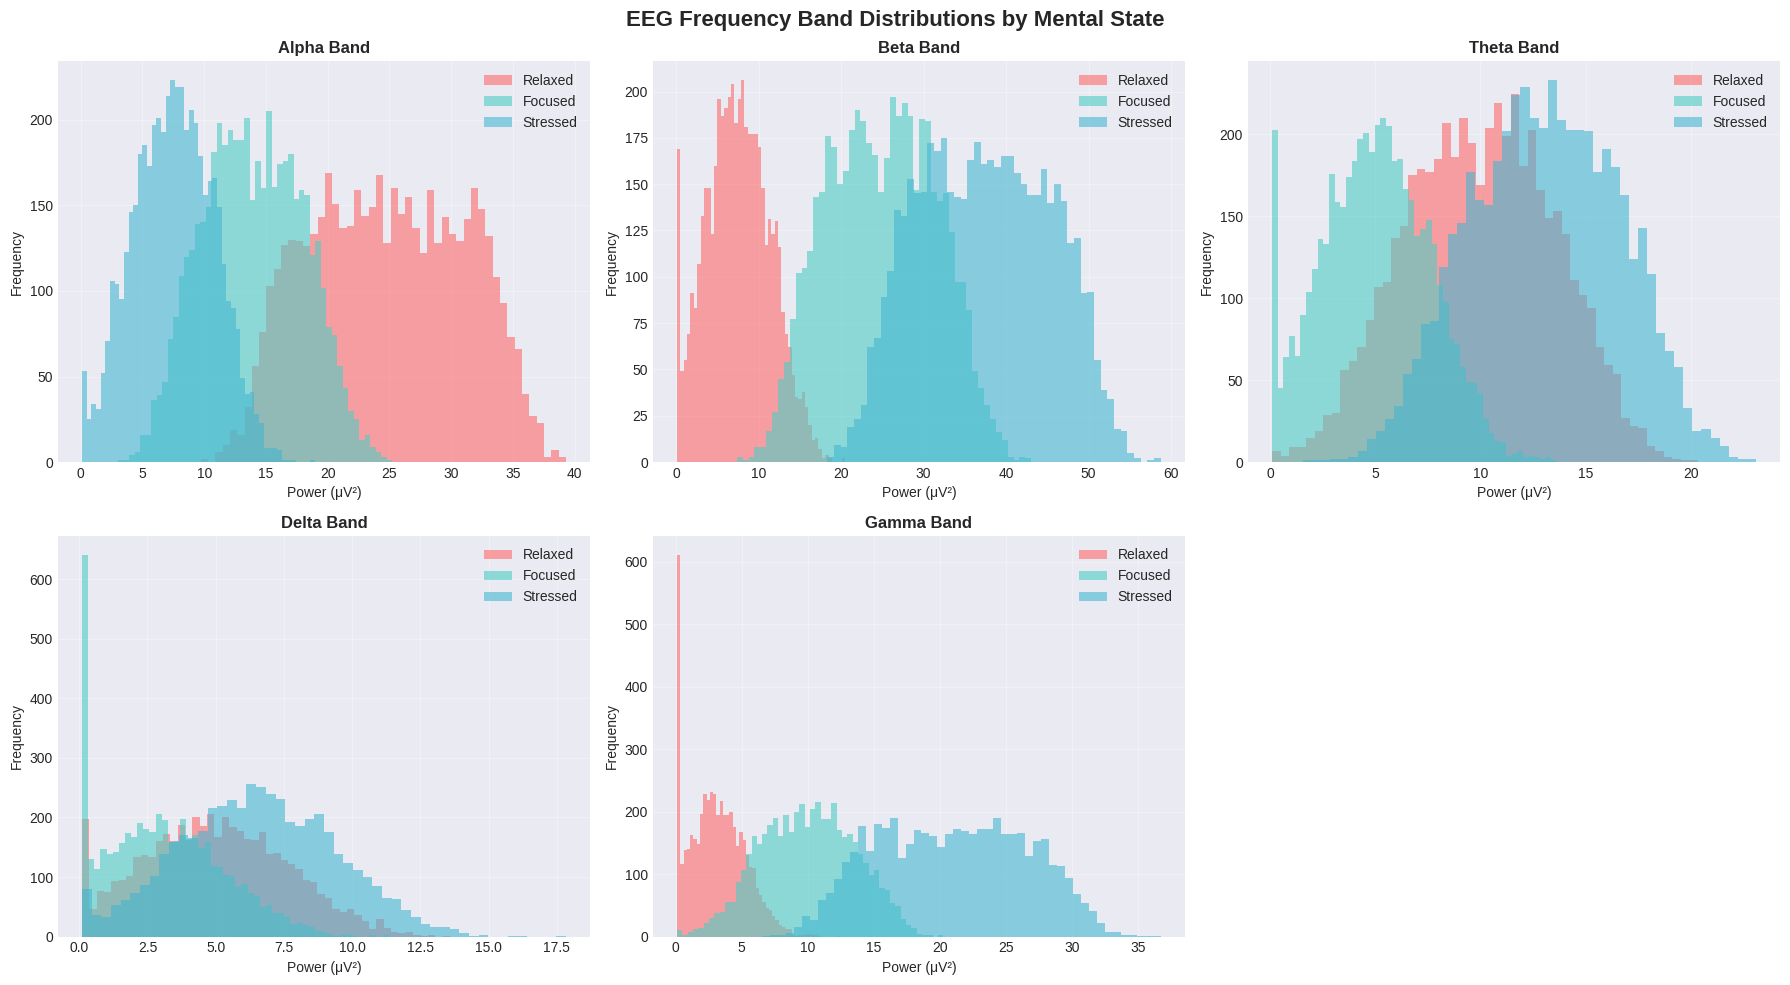

In [7]:
# Distribution of frequency bands by state
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EEG Frequency Band Distributions by Mental State', fontsize=16, fontweight='bold')

bands = ['alpha', 'beta', 'theta', 'delta', 'gamma']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
state_labels = ['Relaxed', 'Focused', 'Stressed']

for idx, band in enumerate(bands):
    ax = axes[idx // 3, idx % 3]
    for state in range(3):
        data = df[df['state'] == state][band]
        ax.hist(data, bins=50, alpha=0.6, label=state_labels[state], color=colors[state])
    ax.set_title(f'{band.capitalize()} Band', fontsize=12, fontweight='bold')
    ax.set_xlabel('Power (μV²)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

/tmp/ipykernel_36694/3918731128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='state_name', y=band, ax=axes[idx], palette='Set2')
/home/polo/Documents/Neurolab/ai/venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/polo/Documents/Neurolab/ai/venv/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/polo/Documents/Neurolab/ai/venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning

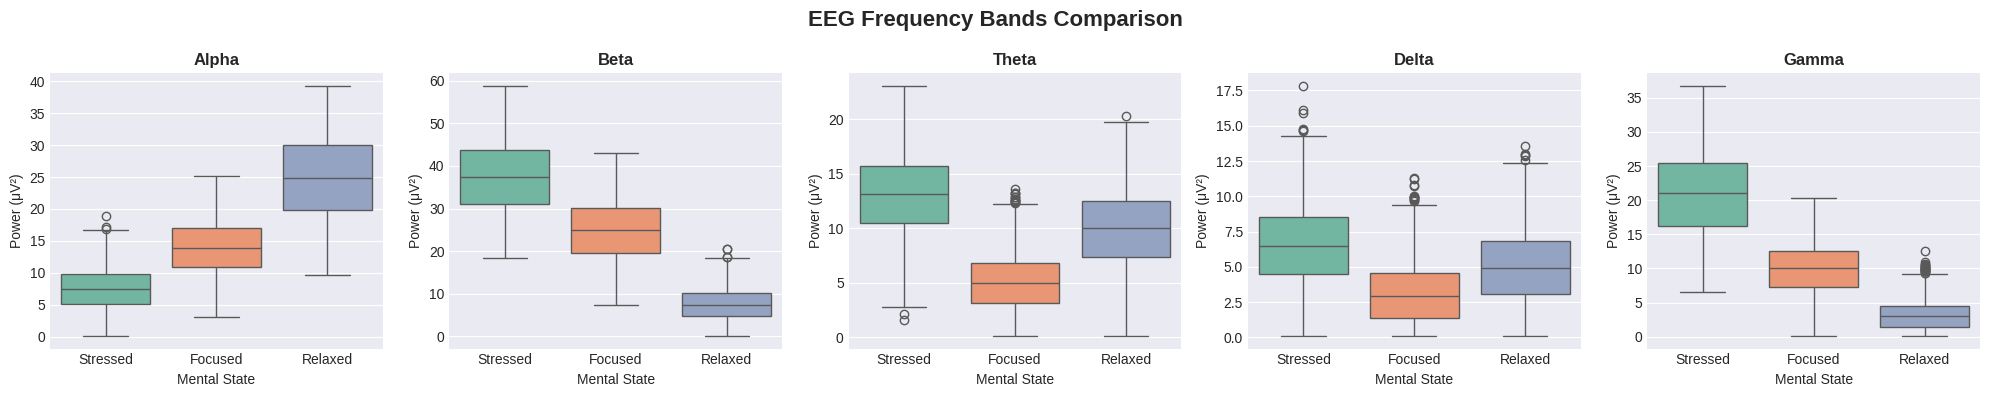

In [8]:
# Box plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('EEG Frequency Bands Comparison', fontsize=16, fontweight='bold')

for idx, band in enumerate(bands):
    df_plot = df.copy()
    df_plot['state_name'] = df_plot['state'].map(state_names)
    sns.boxplot(data=df_plot, x='state_name', y=band, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{band.capitalize()}', fontweight='bold')
    axes[idx].set_xlabel('Mental State')
    axes[idx].set_ylabel('Power (μV²)')

plt.tight_layout()
plt.show()

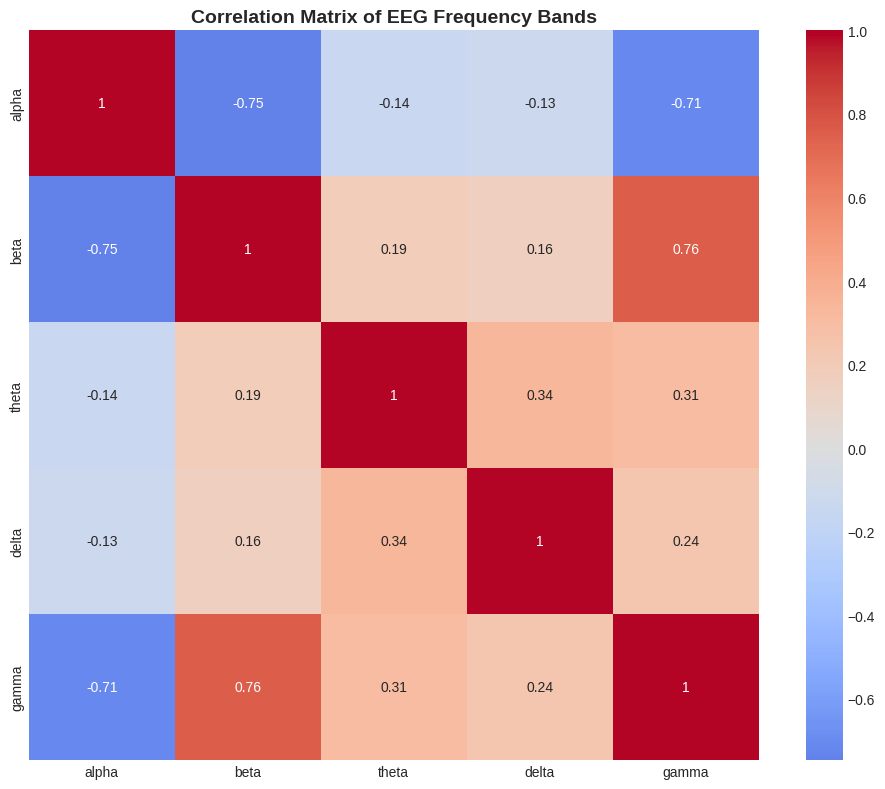

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df[['alpha', 'beta', 'theta', 'delta', 'gamma']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of EEG Frequency Bands', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [10]:
# Create additional features
df['alpha_beta_ratio'] = df['alpha'] / df['beta']
df['theta_beta_ratio'] = df['theta'] / df['beta']
df['total_power'] = df['alpha'] + df['beta'] + df['theta'] + df['delta'] + df['gamma']
df['alpha_percentage'] = (df['alpha'] / df['total_power']) * 100
df['beta_percentage'] = (df['beta'] / df['total_power']) * 100

print("✓ Additional features created")
df[['alpha_beta_ratio', 'theta_beta_ratio', 'total_power']].head()

✓ Additional features created


,alpha_beta_ratio,theta_beta_ratio,total_power
0,0.353549,0.449960,73.907379
1,0.767070,0.004388,50.538860
2,0.167542,0.683950,67.864911
3,2.160900,0.373687,52.832643
4,0.580204,0.257151,61.833539


## 7. Save Dataset

In [11]:
# Save to CSV
output_file = 'eeg_mental_states_dataset.csv'
df.to_csv(output_file, index=False)

print(f"✓ Dataset saved to: {output_file}")
print(f"  Total samples: {len(df)}")
print(f"  Features: {len(df.columns)}")

✓ Dataset saved to: eeg_mental_states_dataset.csv
  Total samples: 15000
  Features: 11
